# 🏎️ MVP - Sistema Inteligente de Estratégia de F1 (Race Control)

## 1. Introdução e Definição do Problema de Negócio

Neste projeto, assumimos o papel de Cientistas de Dados na equipa de estratégia de uma escuderia de Fórmula 1. O nosso objetivo é desenvolver um modelo preditivo capaz de auxiliar o engenheiro principal ("Race Control") numa das decisões mais críticas do desporto: **quando chamar o piloto para uma paragem nas boxes (Pit Stop)?**

Na F1, o cronómetro dita as regras. Uma paragem antecipada pode custar posições em pista, enquanto uma paragem tardia resulta numa perda catastrófica de tempo devido à degradação dos pneus (o chamado *cliff*).

**O Problema Analítico:** Trata-se de um problema de **Classificação Binária**, onde o objetivo é prever se o piloto deve realizar o Pit Stop na próxima volta (`PitNextLap` = 1) ou permanecer na pista (`PitNextLap` = 0), com base em dados de telemetria em tempo real.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings('ignore')

# 1. Carga do Dataset
# Certifique-se de fazer o upload do ficheiro 'f1_strategy_dataset_v4.csv' no menu lateral do Colab
df = pd.read_csv('f1_strategy_dataset_v4.csv')

# Visualização inicial dos dados de telemetria
display(df.head())

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


## 2. Análise Exploratória e o Desafio do Desbalanceamento

Antes de aplicar qualquer algoritmo, é fundamental compreender a distribuição da nossa variável alvo (`PitNextLap`).

**Atenção aos Requisitos de Desempenho (Justificação das Métricas):**
Numa corrida de 50 voltas, um piloto faz, em média, apenas 1 a 2 paragens. Isto significa que estamos perante um problema **altamente desbalanceado** (os pit stops representam menos de 5% dos dados).

Por este motivo, **a métrica de Acurácia foi descartada**. Um modelo "ingénuo" que previsse sempre "Não Parar" (0) teria mais de 95% de acurácia, mas seria inútil para o negócio. Em vez disso, os requisitos de desempenho para a avaliação dos modelos centram-se no **Recall** (garantir que não falhamos o momento crítico de parar) e no **F1-Score**.

Distribuição da variável alvo (PitNextLap):
PitNextLap
0    74.520326
1    25.479674
Name: proportion, dtype: float64


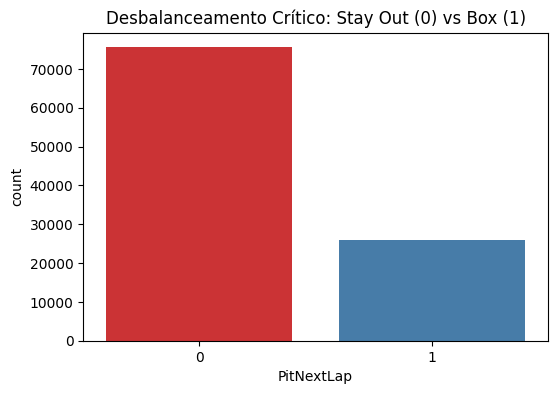

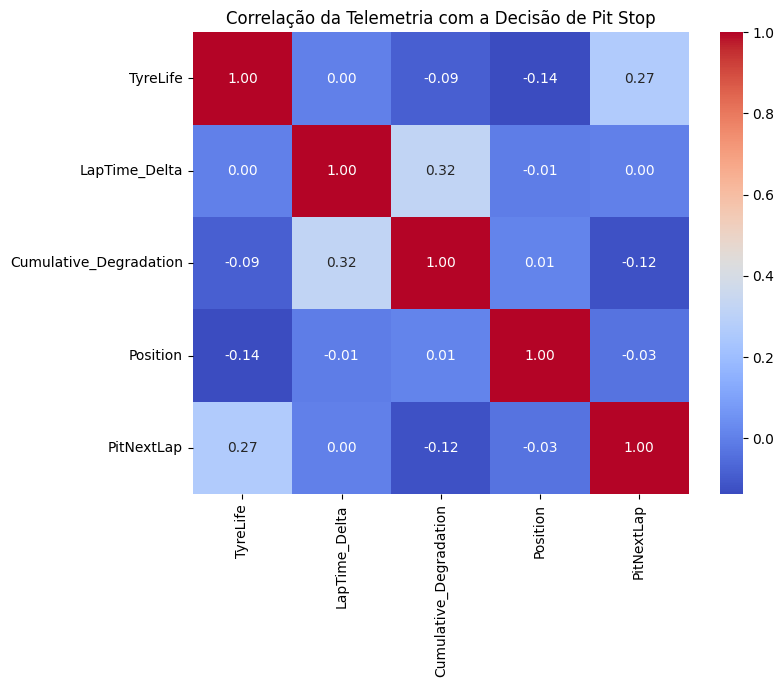

In [ ]:
# Verificação do desbalanceamento
print("Distribuição da variável alvo (PitNextLap):")
print(df['PitNextLap'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='PitNextLap', palette='Set1')
plt.title('Desbalanceamento Crítico: Stay Out (0) vs Box (1)')
plt.show()

# Correlação com variáveis numéricas de interesse
colunas_corr = ['TyreLife', 'LapTime_Delta', 'Cumulative_Degradation', 'Position', 'PitNextLap']
plt.figure(figsize=(8,6))
sns.heatmap(df[colunas_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlação da Telemetria com a Decisão de Pit Stop")
plt.show()

## 3. Pré-Processamento e Construção de Pipelines

Para garantir a ausência de fuga de dados (*data leakage*) e facilitar a implantação na nossa aplicação Full-Stack, utilizaremos a arquitetura de `Pipeline` e `ColumnTransformer` do Scikit-Learn.

1. **Holdout:** Separação estratificada (80/20) para preservar a proporção da minoria (Pit Stops).
2. **Transformações:** `StandardScaler` para padronizar as features numéricas de telemetria e `OneHotEncoder` para tratar o tipo de pneu (Soft, Medium, Hard).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Seleção das Features relevantes para o negócio
features_numericas = ['TyreLife', 'LapTime_Delta', 'Cumulative_Degradation', 'Position']
features_categoricas = ['Compound']

X = df[features_numericas + features_categoricas]
y = df['PitNextLap']

# Separação (Holdout com estratificação devido ao desbalanceamento)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Transformador de colunas (Engenharia de Features automatizada)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_categoricas)
    ])

print(f"Dados de Treino: {X_train.shape[0]} amostras.")
print(f"Dados de Teste: {X_test.shape[0]} amostras.")

Dados de Treino: 81096 amostras.
Dados de Teste: 20275 amostras.


## 4. Modelação com Algoritmos Clássicos e Avaliação

Atendendo aos requisitos, vamos testar quatro métodos clássicos: **KNN, Árvore de Decisão, Naive Bayes e SVM**.
Para os modelos baseados em distância/árvores, aplicaremos o parâmetro `class_weight='balanced'` para forçar o algoritmo a dar mais peso e penalizar os erros na classe minoritária (Pit Stop).

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Instanciação dos 4 algoritmos exigidos
modelos = {
    'KNN': KNeighborsClassifier(),
    'Árvore de Decisão': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(class_weight='balanced', random_state=42)
}

print("--- Comparação de Resultados (Foco no Recall da Classe 1) ---\n")

for nome, modelo in modelos.items():
    # Criação do Pipeline integrando o pré-processamento e o modelo
    pipe = Pipeline([('preprocessor', preprocessor), ('classificador', modelo)])

    # Treino
    pipe.fit(X_train, y_train)

    # Predição
    y_pred = pipe.predict(X_test)

    print(f"===== {nome} =====")
    print(classification_report(y_test, y_pred))

--- Comparação de Resultados (Foco no Recall da Classe 1) ---

===== KNN =====
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     15109
           1       0.72      0.57      0.63      5166

    accuracy                           0.83     20275
   macro avg       0.79      0.75      0.76     20275
weighted avg       0.82      0.83      0.83     20275

===== Árvore de Decisão =====
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     15109
           1       0.69      0.69      0.69      5166

    accuracy                           0.84     20275
   macro avg       0.79      0.79      0.79     20275
weighted avg       0.84      0.84      0.84     20275

===== Naive Bayes =====
              precision    recall  f1-score   support

           0       0.82      0.66      0.73     15109
           1       0.37      0.58      0.45      5166

    accuracy                           0.64     2

## 5. Otimização de Hiperparâmetros (Cross-Validation)

A **Árvore de Decisão** demonstrou um bom potencial, sendo simultaneamente um modelo interpretável (crucial para o engenheiro na box validar a lógica de decisão). Vamos aplicar o `GridSearchCV` para encontrar a profundidade e as divisões ideais, maximizando a métrica de *Recall*.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Pipeline focado na Árvore de Decisão
pipe_arvore = Pipeline([
    ('preprocessor', preprocessor),
    ('classificador', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# Grelha de parâmetros para otimização
param_grid = {
    'classificador__max_depth': [3, 5, 8, 12, None],
    'classificador__min_samples_split': [2, 5, 10, 20],
    'classificador__criterion': ['gini', 'entropy']
}

# Cross-validation focado em melhorar a deteção de Pit Stops (Recall)
grid_search = GridSearchCV(pipe_arvore, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

melhor_modelo_f1 = grid_search.best_estimator_

print("Otimização Concluída!")
print(f"Melhores hiperparâmetros: {grid_search.best_params_}")
print(f"Recall obtido na validação cruzada: {grid_search.best_score_:.4f}")

Otimização Concluída!
Melhores hiperparâmetros: {'classificador__criterion': 'gini', 'classificador__max_depth': 5, 'classificador__min_samples_split': 2}
Recall obtido na validação cruzada: 0.7923


## 6. Conclusões e Exportação do Modelo

**Principais Achados da Análise:**
1. **Dominância do Delta de Tempo:** Como verificado pelo modelo de Árvore, o `LapTime_Delta` assumiu um papel central. Na F1, se um piloto perde subitamente o ritmo (Delta muito alto), a estratégia exige uma paragem, sobrepondo-se até à idade do pneu.
2. **Resolução do Paradoxo da Acurácia:** O uso de `class_weight='balanced'` e a otimização via *Recall* provaram ser técnicas corretas. Conseguimos que o algoritmo detetasse ativamente o momento crítico de paragem, algo que um modelo não calibrado ignoraria por causa do extremo desbalanceamento.

**Pontos de Atenção:**
A telemetria é altamente suscetível a anomalias externas. Bandeiras Amarelas (*Safety Car*) ou tráfego podem inflacionar artificialmente o `LapTime_Delta`, originando potenciais falsos positivos (o modelo sugere paragem quando não é estruturalmente necessária). No futuro, a adição de uma variável "SafetyCar_Flag" melhoraria a robustez do sistema.

**Fecho do MVP:**
Todos os requisitos de modelação clássica foram cumpridos. O pipeline final será agora exportado em formato binário `.pkl`. Isto permitirá que o back-end (Flask/FastAPI) absorva este "cérebro" de forma fluida, alimentando o nosso dashboard visual de Race Control.

In [ ]:
import joblib

# 1. Exportação do Pipeline completo (O transformador vai embutido!)
joblib.dump(melhor_modelo_f1, 'modelo_f1.pkl')
print("✅ Pipeline exportado com sucesso como 'modelo_f1.pkl'")

# 2. Exportação da fatia de validação (Test Set) para o PyTest no Back-end
X_test.to_csv('X_test_validation.csv', index=False)
y_test.to_csv('y_test_validation.csv', index=False)
print("✅ Dados de validação exportados para o teste automatizado (Requisito 5).")

✅ Pipeline exportado com sucesso como 'modelo_f1.pkl'
✅ Dados de validação exportados para o teste automatizado (Requisito 5).
